<a href="https://colab.research.google.com/github/ayodyasenavirathne/Ayodya_Senavirathne-11316/blob/main/Student_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [12]:
np.random.seed(42)

data = {
    "study_hours": np.random.randint(1,10,200),
    "sleep_hours": np.random.randint(4,9,200),
    "attendance": np.random.randint(60,100,200),
    "internet_usage": np.random.randint(1,8,200),
    "previous_grade": np.random.randint(40,95,200),
}

df = pd.DataFrame(data)

df["final_grade"] = (
    df["study_hours"]*5 +
    df["sleep_hours"]*2 +
    df["attendance"]*0.3 +
    df["previous_grade"]*0.5 -
    df["internet_usage"]*2 +
    np.random.normal(0,5,200)
)

df.head()

,study_hours,sleep_hours,attendance,internet_usage,previous_grade,final_grade
0,7,4,90,5,47,92.046462
1,4,6,69,6,88,88.824501
2,8,7,78,2,74,119.261890
3,5,4,91,3,91,97.808133
4,7,4,60,5,54,79.250952


In [13]:
df.shape

(200, 6)

In [14]:
df.describe()

,study_hours,sleep_hours,attendance,internet_usage,previous_grade,final_grade
count,200.00000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,5.07000,5.975000,80.240000,3.865000,65.795000,86.837118
std,2.63435,1.450827,11.219706,2.056189,16.116815,17.428092
min,1.00000,4.000000,60.000000,1.000000,40.000000,46.928648
25%,3.00000,5.000000,71.000000,2.000000,51.000000,74.967495
50%,5.00000,6.000000,80.000000,4.000000,65.000000,86.356990
75%,7.00000,7.000000,90.000000,6.000000,79.000000,98.228988
max,9.00000,8.000000,99.000000,7.000000,94.000000,133.958917


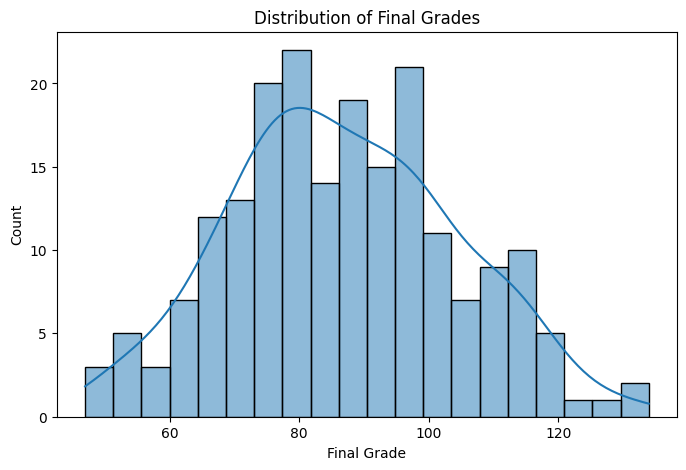

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df["final_grade"],bins=20,kde=True)

plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade")
plt.show()

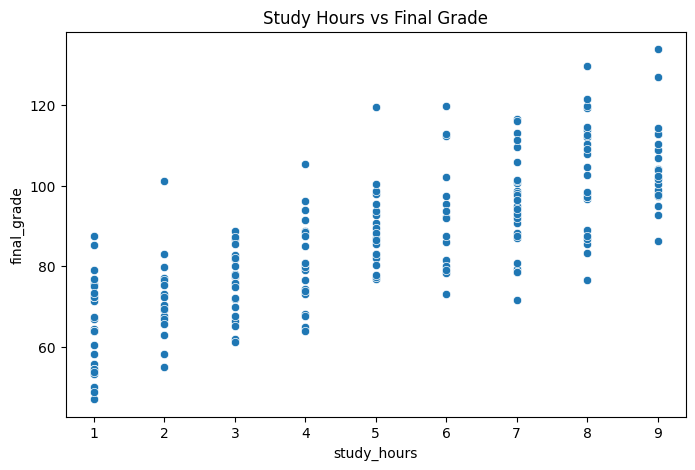

In [16]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="study_hours",y="final_grade",data=df)

plt.title("Study Hours vs Final Grade")
plt.show()

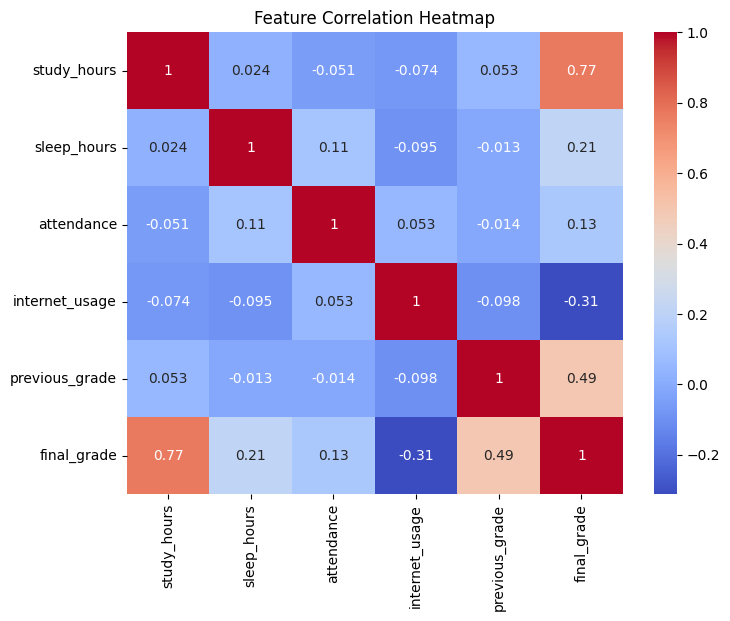

In [17]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(),annot=True,cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()

In [18]:
X = df.drop("final_grade",axis=1)

y = df["final_grade"]

In [19]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [20]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
lr = LinearRegression()

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

In [22]:
print("Linear Regression Results")

print("MAE:",mean_absolute_error(y_test,pred_lr))
print("MSE:",mean_squared_error(y_test,pred_lr))
print("R2:",r2_score(y_test,pred_lr))

Linear Regression Results
MAE: 3.8659350408734676
MSE: 25.1692367047202
R2: 0.9303976974522251


In [23]:
rf = RandomForestRegressor(n_estimators=100,random_state=42)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

In [24]:
print("Random Forest Results")

print("MAE:",mean_absolute_error(y_test,pred_rf))
print("MSE:",mean_squared_error(y_test,pred_rf))
print("R2:",r2_score(y_test,pred_rf))

Random Forest Results
MAE: 4.5843333200448155
MSE: 37.74328591458061
R2: 0.8956257737891136


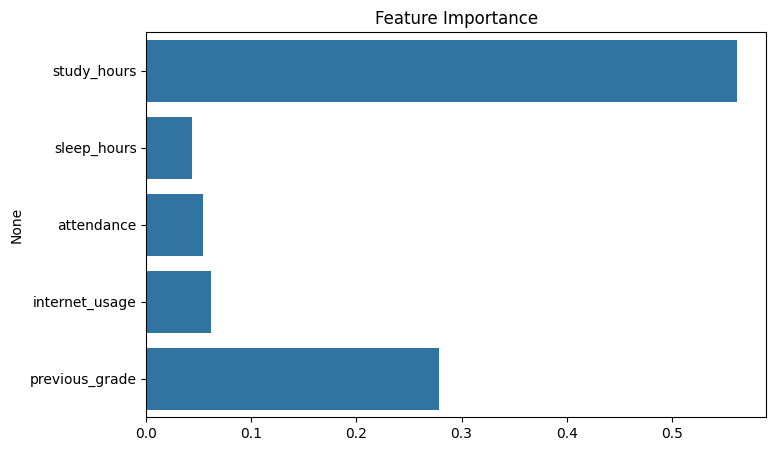

In [25]:
importance = rf.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))

sns.barplot(x=importance,y=features)

plt.title("Feature Importance")
plt.show()